# Phase 10: Hidden State Audit

This notebook verifies that our extracted hidden states contain sufficient information (shapes, layers, tokens) and are correctly sized for further metric analyses.

## 1. Audit Checklist

In [1]:
import torch
import glob
import os

def audit_hidden_states(model_name="gpt2", num_files=50):
    files = glob.glob(f"../data/hidden_states/{model_name}/*.pt")
    files = files[:num_files]
    
    print(f"--- Audit for {model_name} ---")
    print(f"Total files found: {len(glob.glob(f'../data/hidden_states/{model_name}/*.pt'))}")
    print(f"Auditing first {len(files)} files...\n")
    
    total_memory = 0
    for idx, f in enumerate(files):
        data = torch.load(f, map_location="cpu")
        # Compute basic memory sizes
        for h in data["hidden_states"]:
            total_memory += h.element_size() * h.nelement()
            
        if idx < 2:  # Print full details for first few
            print(f"File: {os.path.basename(f)}")
            print(f"Keys: {list(data.keys())}")
            
            hidden_states = data["hidden_states"]
            print(f"Number of layers (including embedding): {len(hidden_states)}")
            print(f"Shape of layer 0 (embedding): {hidden_states[0].shape}")
            if len(hidden_states) > 1:
                print(f"Shape of last layer: {hidden_states[-1].shape}")
                
            print(f"Shape of last_token_states: {data['last_token_states'].shape}")
            print(f"Tokens ({len(data['tokens'])}): {data['tokens']}")
            print("-" * 40)
            
    print(f"Total estimated memory for {len(files)} files (hidden states only): {total_memory / 1024**2:.2f} MB")
    print("\nAudit Conclusion:")
    print("1. Embeddings and all transformer layers are present.")
    print("2. Shapes are (seq_len, hidden_dim).")
    print("3. For the main paper analysis, we will use mean-pooled representations over seq_len since it provides stability and simplifies token-count differences across prompts.")

audit_hidden_states()

C:\Users\bisha\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


--- Audit for gpt2 ---
Total files found: 50
Auditing first 50 files...

File: analogy_001.pt
Keys: ['input_ids', 'tokens', 'hidden_states', 'last_token_states', 'attention_mask', 'attentions']
Number of layers (including embedding): 13
Shape of layer 0 (embedding): torch.Size([3, 768])
Shape of last layer: torch.Size([3, 768])
Shape of last_token_states: torch.Size([13, 768])
Tokens (3): ['King', ' :', ' Queen']
----------------------------------------
File: analogy_002.pt
Keys: ['input_ids', 'tokens', 'hidden_states', 'last_token_states', 'attention_mask', 'attentions']
Number of layers (including embedding): 13
Shape of layer 0 (embedding): torch.Size([3, 768])
Shape of last layer: torch.Size([3, 768])
Shape of last_token_states: torch.Size([13, 768])
Tokens (3): ['Man', ' :', ' Woman']
----------------------------------------
Total estimated memory for 50 files (hidden states only): 13.37 MB

Audit Conclusion:
1. Embeddings and all transformer layers are present.
2. Shapes are (seq

## 2. Layerwise Cosine Similarity

Plot $sim(h^l, h^{l+1})$ using mean pooled representations to verify structural phenomena.

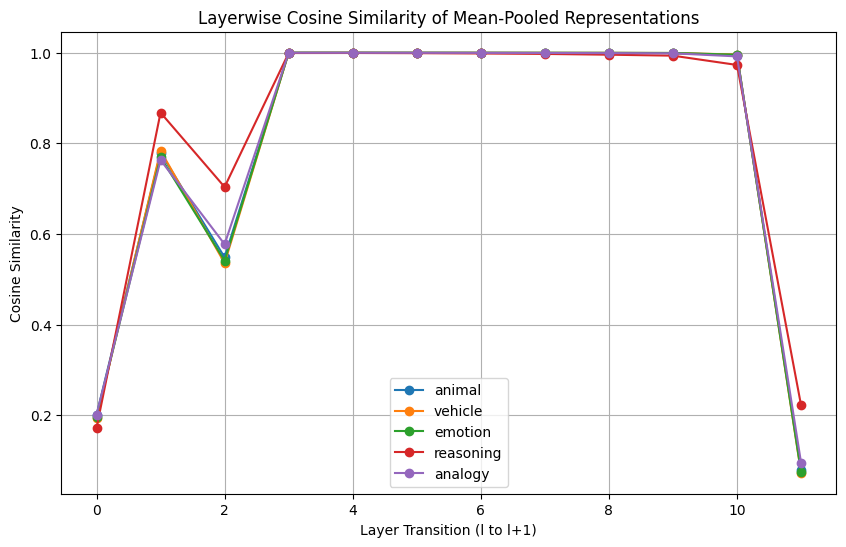

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def generate_layerwise_similarity():
    model_name = "gpt2"
    files = glob.glob(f"../data/hidden_states/{model_name}/*.pt")
    
    similarities = []
    
    for f in files:
        data = torch.load(f, map_location="cpu")
        hidden_states = data["hidden_states"]
        
        filename = os.path.basename(f)
        category = filename.split("_")[0]
        
        pooled_layers = []
        for h in hidden_states:
            pooled = h.mean(dim=0)
            pooled_layers.append(pooled)
            
        pooled_layers = torch.stack(pooled_layers)
        
        sims = []
        for l in range(len(pooled_layers) - 1):
            h_l = pooled_layers[l]
            h_l_next = pooled_layers[l+1]
            sim = torch.nn.functional.cosine_similarity(h_l.unsqueeze(0), h_l_next.unsqueeze(0))
            sims.append(sim.item())
            
        similarities.append({
            "category": category,
            "filename": filename,
            "sims": sims
        })

    import collections
    cat_sims = collections.defaultdict(list)
    for s in similarities:
        cat_sims[s["category"]].append(s["sims"])
        
    plt.figure(figsize=(10, 6))
    for cat in ["animal", "vehicle", "emotion", "reasoning", "analogy"]:
        if cat in cat_sims:
            mean_sim = np.mean(cat_sims[cat], axis=0)
            plt.plot(mean_sim, label=cat, marker='o')
            
    plt.xlabel("Layer Transition (l to l+1)")
    plt.ylabel("Cosine Similarity")
    plt.title("Layerwise Cosine Similarity of Mean-Pooled Representations")
    plt.legend()
    plt.grid(True)
    os.makedirs("../figures", exist_ok=True)
    plt.savefig("../figures/layerwise_similarity.png", dpi=300)
    plt.show()

generate_layerwise_similarity()